In [1]:
# ==========================================
# 1. INSTALL & IMPORT DEPENDENCIES
# ==========================================
# !pip install yfinance pandas scikit-learn matplotlib
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import pickle

In [2]:
# ==========================================
# 2. DATA ACQUISITION (Live from yfinance)
# ==========================================
# Tickers: Gold, S&P 500, VIX, Oil, Silver, EUR/USD
tickers = ['GC=F', '^GSPC', '^VIX', 'USO', 'SLV', 'EURUSD=X']

print("🔄 Fetching historical market data (2000 - Present)...")
# We download the 'Close' price for all assets
raw_data = yf.download(tickers, start="2000-01-01", interval="1d")['Close']

🔄 Fetching historical market data (2000 - Present)...


[*********************100%***********************]  6 of 6 completed


In [3]:
# ==========================================
# 3. DATA CLEANING & FEATURE MAPPING
# ==========================================
# yfinance returns columns in alphabetical order by ticker
# Mapping: EURUSD=X -> EURUSD, GC=F -> GLD, SLV -> SLV, USO -> USO, ^GSPC -> SPX, ^VIX -> VIX
df = raw_data.copy()
df.columns = ['EURUSD', 'GLD', 'SLV', 'USO', 'SPX', 'VIX']

# Drop missing values (weekends/holidays when some markets are closed)
df = df.dropna()

print(f"✅ Data processed. Total training samples: {len(df)}")
print(df.head())

✅ Data processed. Total training samples: 5006
              EURUSD         GLD     SLV         USO          SPX    VIX
Date                                                                    
2006-04-28  1.263600  651.799988  13.812  556.960022  1310.609985  11.59
2006-05-01  1.258004  657.500000  13.870  572.000000  1305.189941  12.54
2006-05-02  1.261702  664.700012  14.365  578.719971  1313.209961  11.99
2006-05-03  1.262307  665.900024  13.925  561.760010  1308.119995  11.99
2006-05-04  1.270099  674.200012  14.000  546.559998  1312.250000  11.86


In [4]:
# ==========================================
# 4. TRAIN/TEST SPLIT
# ==========================================
# X = Market Features | Y = Gold Price (GLD)
X = df[['SPX', 'VIX', 'USO', 'SLV', 'EURUSD']]
Y = df['GLD']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [5]:
# ==========================================
# 5. MODEL TRAINING (Optimized for Web)
# ==========================================
# max_depth=10 ensures the file stays around 12MB-19MB for GitHub
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

print("🧠 Training Random Forest Regressor...")
model.fit(X_train, Y_train)

🧠 Training Random Forest Regressor...


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



--- Model Performance ---
R-Squared (Accuracy): 0.9973
Mean Absolute Error: $26.23


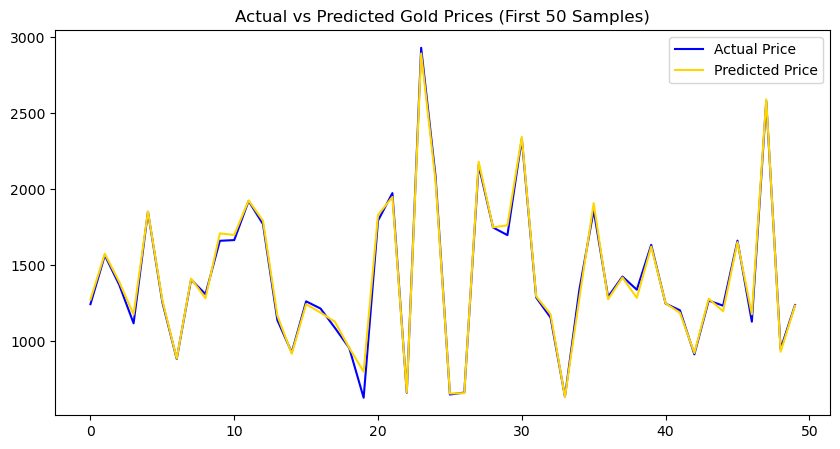

In [6]:
# ==========================================
# 6. EVALUATION
# ==========================================
predictions = model.predict(X_test)
score = metrics.r2_score(Y_test, predictions)
mae = metrics.mean_absolute_error(Y_test, predictions)

print(f"\n--- Model Performance ---")
print(f"R-Squared (Accuracy): {score:.4f}")
print(f"Mean Absolute Error: ${mae:.2f}")

# Visualizing results
plt.figure(figsize=(10,5))
plt.plot(list(Y_test)[:50], color='blue', label='Actual Price')
plt.plot(predictions[:50], color='gold', label='Predicted Price')
plt.title('Actual vs Predicted Gold Prices (First 50 Samples)')
plt.legend()
plt.show()

In [7]:
# ==========================================
# 7. EXPORTING THE BRAIN
# ==========================================
filename = 'gold_model.pkl'
pickle.dump(model, open(filename, 'wb'))
print(f"\n🚀 Success! '{filename}' has been generated without using any CSV files.")


🚀 Success! 'gold_model.pkl' has been generated without using any CSV files.
